In [1]:
from IPython.core.interactiveshell import InteractiveShell
%load_ext autoreload
InteractiveShell.ast_node_interactivity = "all"
import logging
logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(name)s - %(levelname)s - %(message)s"
)

In [2]:
import numpy as np
import pandas as pd
import os
import sys
import matplotlib.pyplot as plt

module_path = os.path.abspath(
    os.path.join("/cmnfs/proj/ORIGINS/protMSD/maxquant/ScanByScan/swaps")
)
if module_path not in sys.path:
    sys.path.append(module_path)

2025-01-23 16:29:00,794 - numexpr.utils - INFO - Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
2025-01-23 16:29:00,796 - numexpr.utils - INFO - NumExpr defaulting to 8 threads.
/cmnfs/home/z.xiao/miniconda3/envs/sbs/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# MQ MBR result

In [133]:
evidence_MBR = pd.read_csv(
    "/cmnfs/proj/ORIGINS/data/HeLa_sample_amount_and_LC_columns/30min_5ug_ref/txt_30min_5ug_MBR/evidence.txt",
    sep="\t",
)
evidence_MBR["Raw file"].unique()
evidence_MBR = evidence_MBR.loc[evidence_MBR["Reverse"] != "+", :]

/tmp/ipykernel_2118122/705027787.py:1: DtypeWarning: Columns (61) have mixed types. Specify dtype option on import or set low_memory=False.
  evidence_MBR = pd.read_csv(


array(['Hela_30min_5ug_R2_RA1_1_5163', 'Hela_30min_5ug_R3_RA1_1_5164',
       'Hela_30min_5ug_R1_RA1_1_5162'], dtype=object)

In [134]:
MBR_R1 = evidence_MBR[evidence_MBR["Raw file"] == "Hela_30min_5ug_R1_RA1_1_5162"]
MBR_R2 = evidence_MBR[evidence_MBR["Raw file"] == "Hela_30min_5ug_R2_RA1_1_5163"]
MBR_R3 = evidence_MBR[evidence_MBR["Raw file"] == "Hela_30min_5ug_R3_RA1_1_5164"]

In [159]:
def sum_intensity(df):
    df = df.groupby(
        ["Mod. peptide ID", "Charge", "Type", "Raw file"], as_index=False
    ).agg({"Intensity": ["sum", "count"]})
    df.columns = [
        "Mod. peptide ID",
        "Charge",
        "Type",
        "Raw file",
        "Intensity_sum",
        "Intensity_count",
    ]
    return df

In [160]:
evidence_MBR_sum = sum_intensity(evidence_MBR)

In [136]:
MBR_R1_sum = sum_intensity(MBR_R1)
MBR_R2_sum = sum_intensity(MBR_R2)
MBR_R3_sum = sum_intensity(MBR_R3)

In [137]:
MBR_R1_sum["Intensity_count"].value_counts()

Intensity_count
1    57552
2      850
3       49
4        4
5        1
7        1
Name: count, dtype: int64

In [138]:
MQ_R1_R2 = pd.merge(
    MBR_R1_sum,
    MBR_R2_sum,
    on=["Mod. peptide ID", "Charge"],
    suffixes=("_R1", "_R2"),
)
MQ_R2_R3 = pd.merge(MBR_R2_sum, MBR_R3_sum, on=["Mod. peptide ID", "Charge"])
MQ_R2_R3 = pd.merge(
    MBR_R1_sum,
    MBR_R3_sum,
    on=["Mod. peptide ID", "Charge"],
    suffixes=("_R1", "_R3"),
)

## Identification count point

<Figure size 300x600 with 0 Axes>

Text(0, 27000, '51542')

Text(1, 27000, '51702')

Text(2, 27000, '51772')

Text(0, 54000, '6915')

...

Text(2, 54000, '7699')

(array([0, 1, 2]),
 [Text(0, 0, 'Hela_30min_5ug_R1_RA1_1_5162'),
  Text(1, 0, 'Hela_30min_5ug_R2_RA1_1_5163'),
  Text(2, 0, 'Hela_30min_5ug_R3_RA1_1_5164')])

([<matplotlib.axis.XTick at 0x7efc28c11780>,
 [Text(0, 0, 'R1'), Text(1, 0, 'R2'), Text(2, 0, 'R3')])

Text(0.5, 0, 'Experiment')

<Figure size 300x600 with 0 Axes>

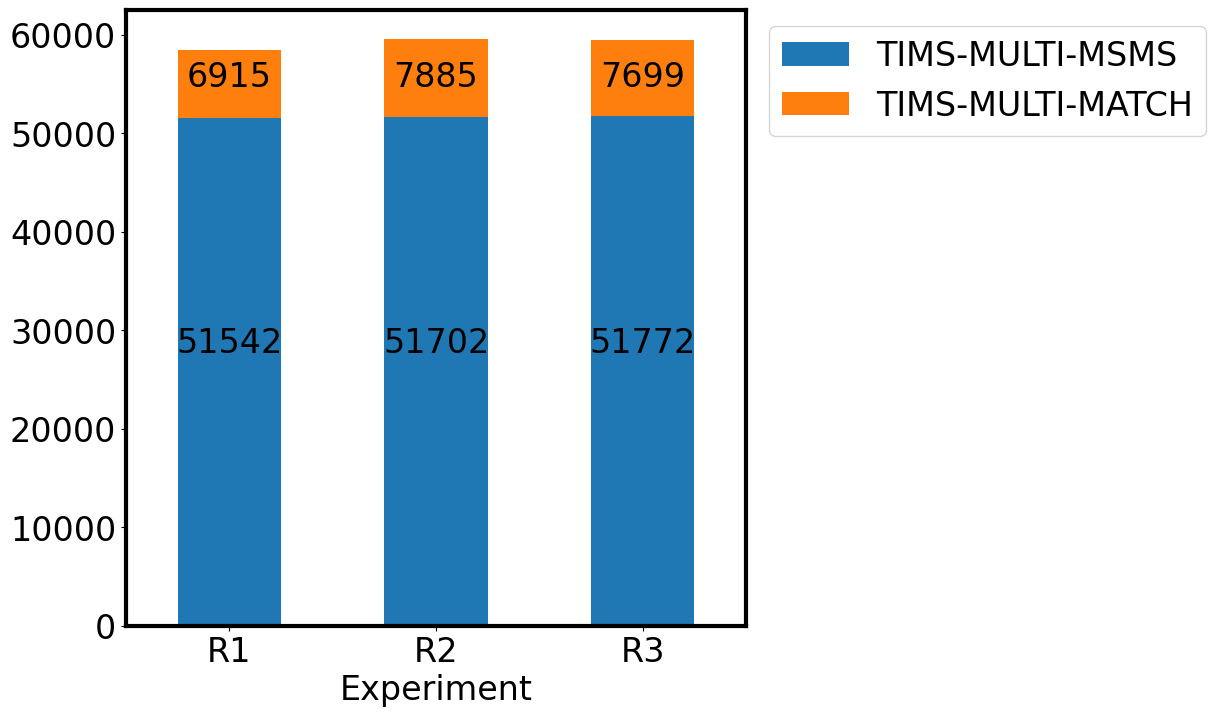

In [162]:
import matplotlib.pyplot as plt

plt.rc("font", size=24)  # Set the default font size for all text elements
plt.figure(figsize=(3, 6))  # Set the size of the figure
evidence_MBR_sum["count"] = 1
evidence_MBR_sum_pivot = evidence_MBR_sum.pivot_table(
    index="Raw file",
    columns="Type",
    values="count",
    aggfunc="sum",
    fill_value=0,
)
evidence_MBR_sum_pivot = evidence_MBR_sum_pivot[["TIMS-MULTI-MSMS", "TIMS-MULTI-MATCH"]]
ax = evidence_MBR_sum_pivot.plot(
    kind="bar",
    stacked=True,
    legend=True,
    # hue_order=["TIMS-MULTI-MSMS", "TIMS-MULTI-MATCH"],
)
ax.legend(bbox_to_anchor=(1.01, 1))
for idx_col, col in enumerate(evidence_MBR_sum_pivot.columns):
    for idx, val in enumerate(evidence_MBR_sum_pivot.index):
        ax.text(
            x=idx,
            y=(idx_col + 1) * 27000,
            s=f"{evidence_MBR_sum_pivot.loc[val, col]}",
            ha="center",
            va="bottom",
        )
for spine in ax.spines.values():
    spine.set_linewidth(3)  # Increase this value for thicker lines
plt.xticks(rotation=0)
plt.xticks([0, 1, 2], ["R1", "R2", "R3"])
plt.xlabel("Experiment")
# plt.savefig(
#     "/cmnfs/proj/ORIGINS/SWAPS_exp/SWAPS_paper_figures/revision/comparison_MBR/swap_mq_id.png",
#     bbox_inches="tight",
#     dpi=300,
# )

In [163]:
58457 / 64828
59587 / 64828
59471 / 64828

0.9017245634602332

0.9191553032640217

0.9173659529832788

## Run-to-run pair-wise correlation

In [140]:
# All ID results
from utils.plot import plot_scatter

reg_int, abs_residue, valid_idx = plot_scatter(
    x=MQ_R1_R2["Intensity_sum_R1"],
    y=MQ_R1_R2["Intensity_sum_R2"],
    title="",
    x_label="MaxQuant Intensity R1 (Log10)",
    y_label="MaxQuant Intensity R2 (Log10)",
    log_x=True,
    log_y=True,
    font_size=20,
    save_dir="/cmnfs/proj/ORIGINS/SWAPS_exp/SWAPS_paper_figures/revision/comparison_MBR/",
    fig_spec_name="scatter_MQ_all_R1_R2",
)

2025-01-20 14:17:09,261 - utils.plot - INFO - Data: Intensity_sum_R1_log, Intensity_sum_R2_log, slope = 0.814, intercept = 0.918, Pearson's R = 0.775, Spearman's R = 0.887


2025-01-20 14:18:03,727 - utils.plot - INFO - Save plot at /cmnfs/proj/ORIGINS/SWAPS_exp/SWAPS_paper_figures/revision/comparison_MBR/CorrQuantification_Intensity_sum_R2_logscatter_MQ_all_R1_R2.png
2025-01-20 14:18:07,603 - utils.plot - INFO - Save plot at /cmnfs/proj/ORIGINS/SWAPS_exp/SWAPS_paper_figures/revision/comparison_MBR/CorrQuantification_Intensity_sum_R2_logscatter_MQ_all_R1_R2.svg


In [142]:
# MSMSdd ID results
from utils.plot import plot_scatter

MQ_R1_R2_MSMS = MQ_R1_R2.loc[
    (MQ_R1_R2["Type_R1"] == "TIMS-MULTI-MSMS")
    & (MQ_R1_R2["Type_R2"] == "TIMS-MULTI-MSMS")
]
reg_int, abs_residue, valid_idx = plot_scatter(
    x=MQ_R1_R2_MSMS["Intensity_sum_R1"],
    y=MQ_R1_R2_MSMS["Intensity_sum_R2"],
    title="",
    x_label="MaxQuant Intensity R1 (Log10)",
    y_label="MaxQuant Intensity R2 (Log10)",
    log_x=True,
    log_y=True,
    font_size=20,
    save_dir="/cmnfs/proj/ORIGINS/SWAPS_exp/SWAPS_paper_figures/revision/comparison_MBR/",
    fig_spec_name="scatter_MQ_msms_R1_R2",
)

2025-01-20 14:18:17,362 - utils.plot - INFO - Data: Intensity_sum_R1_log, Intensity_sum_R2_log, slope = 0.994, intercept = 0.029, Pearson's R = 0.991, Spearman's R = 0.991
2025-01-20 14:18:49,978 - utils.plot - INFO - Save plot at /cmnfs/proj/ORIGINS/SWAPS_exp/SWAPS_paper_figures/revision/comparison_MBR/CorrQuantification_Intensity_sum_R2_logscatter_MQ_msms_R1_R2.png
2025-01-20 14:18:52,995 - utils.plot - INFO - Save plot at /cmnfs/proj/ORIGINS/SWAPS_exp/SWAPS_paper_figures/revision/comparison_MBR/CorrQuantification_Intensity_sum_R2_logscatter_MQ_msms_R1_R2.svg


In [143]:
# Match ID results
from utils.plot import plot_scatter

MQ_R1_R2_MATCH = MQ_R1_R2.loc[
    (MQ_R1_R2["Type_R1"] != "TIMS-MULTI-MSMS")
    | (MQ_R1_R2["Type_R2"] != "TIMS-MULTI-MSMS")
]

reg_int, abs_residue, valid_idx = plot_scatter(
    x=MQ_R1_R2_MATCH["Intensity_sum_R1"],
    y=MQ_R1_R2_MATCH["Intensity_sum_R2"],
    title="",
    x_label="MaxQuant Intensity R1 (Log10)",
    y_label="MaxQuant Intensity R2 (Log10)",
    log_x=True,
    log_y=True,
    font_size=20,
    save_dir="/cmnfs/proj/ORIGINS/SWAPS_exp/SWAPS_paper_figures/revision/comparison_MBR/",
    fig_spec_name="scatter_MQ_match_R1_R2",
)

2025-01-20 14:22:06,902 - utils.plot - INFO - Data: Intensity_sum_R1_log, Intensity_sum_R2_log, slope = 0.098, intercept = 4.111, Pearson's R = 0.092, Spearman's R = 0.346


2025-01-20 14:22:10,881 - utils.plot - INFO - Save plot at /cmnfs/proj/ORIGINS/SWAPS_exp/SWAPS_paper_figures/revision/comparison_MBR/CorrQuantification_Intensity_sum_R2_logscatter_MQ_match_R1_R2.png
2025-01-20 14:22:11,862 - utils.plot - INFO - Save plot at /cmnfs/proj/ORIGINS/SWAPS_exp/SWAPS_paper_figures/revision/comparison_MBR/CorrQuantification_Intensity_sum_R2_logscatter_MQ_match_R1_R2.svg


In [144]:
# Match ID results
MQ_R1_R2_MATCH_filtered = MQ_R1_R2_MATCH.loc[
    (MQ_R1_R2_MATCH["Intensity_count_R1"] == 1)
    & (MQ_R1_R2_MATCH["Intensity_count_R2"] == 1)
]
reg_int, abs_residue, valid_idx = plot_scatter(
    x=MQ_R1_R2_MATCH_filtered["Intensity_sum_R1"],
    y=MQ_R1_R2_MATCH_filtered["Intensity_sum_R2"],
    title="",
    x_label="MaxQuant Intensity R1 (Log10)",
    y_label="MaxQuant Intensity R2 (Log10)",
    log_x=True,
    log_y=True,
    font_size=20,
    save_dir="/cmnfs/proj/ORIGINS/SWAPS_exp/SWAPS_paper_figures/revision/comparison_MBR/",
    fig_spec_name="scatter_MQ_match_filter_multi_elution_R1_R2",
)

2025-01-20 14:22:14,181 - utils.plot - INFO - Data: Intensity_sum_R1_log, Intensity_sum_R2_log, slope = 0.106, intercept = 4.059, Pearson's R = 0.099, Spearman's R = 0.37


2025-01-20 14:22:17,852 - utils.plot - INFO - Save plot at /cmnfs/proj/ORIGINS/SWAPS_exp/SWAPS_paper_figures/revision/comparison_MBR/CorrQuantification_Intensity_sum_R2_logscatter_MQ_match_filter_multi_elution_R1_R2.png
2025-01-20 14:22:18,808 - utils.plot - INFO - Save plot at /cmnfs/proj/ORIGINS/SWAPS_exp/SWAPS_paper_figures/revision/comparison_MBR/CorrQuantification_Intensity_sum_R2_logscatter_MQ_match_filter_multi_elution_R1_R2.svg


# SWAPS MBR

In [5]:
def read_swaps_result(result_path, spec_dir: str = "", read_ps: bool = True):
    maxquant_result_ref = pd.read_pickle(
        os.path.join(result_path, "maxquant_result_ref.pkl")
    )
    if read_ps:
        ps_act = pd.read_csv(
            os.path.join(result_path, "peak_selection", spec_dir, "pept_act_sum_ps.csv")
        )
    else:
        ps_act = pd.read_csv(
            os.path.join(
                result_path, "results", "activation", "pept_act_sum_filter_by_im.csv"
            )
        )
    ps_act_full_df = pd.merge(
        left=ps_act, right=maxquant_result_ref, on=["mz_rank"], how="left"
    )
    return ps_act_full_df

In [ ]:
# No Peak Selection
result_path = "/cmnfs/proj/ORIGINS/SWAPS_exp/short_gradient/30min_3to45_7R_30min_exp_library_no_decoy_MBR_R2_20250113_135150_122755"
R2 = read_swaps_result(result_path, spec_dir, read_ps=False)
result_path = "/cmnfs/proj/ORIGINS/SWAPS_exp/short_gradient/30min_3to45_7R_30min_exp_library_no_decoy_MBR_R3_20250113_141233_668739"
R3 = read_swaps_result(result_path, spec_dir, read_ps=False)
result_path = "/cmnfs/proj/ORIGINS/SWAPS_exp/short_gradient/30min_3to45_7R_30min_exp_library_no_decoy_MBR_R1_20250113_141233_681815"
R1 = read_swaps_result(result_path, spec_dir, read_ps=False)
R1.rename(columns={"pept_act_sum_filter_by_im": "sum_intensity"}, inplace=True)
R2.rename(columns={"pept_act_sum_filter_by_im": "sum_intensity"}, inplace=True)
R3.rename(columns={"pept_act_sum_filter_by_im": "sum_intensity"}, inplace=True)

In [8]:
R1_R2 = pd.merge(
    R1[
        [
            "Sequence",
            "Modifications",
            "Modified sequence",
            "Charge",
            "sum_intensity",
            "source",
        ]
    ],
    R2[
        [
            "Sequence",
            "Modifications",
            "Modified sequence",
            "Charge",
            "sum_intensity",
            "source",
        ]
    ],
    on=["Sequence", "Modifications", "Modified sequence", "Charge"],
    suffixes=("_R1", "_R2"),
)
R2_R3 = pd.merge(
    R2[
        [
            "Sequence",
            "Modifications",
            "Modified sequence",
            "Charge",
            "sum_intensity",
            "source",
        ]
    ],
    R3[
        [
            "Sequence",
            "Modifications",
            "Modified sequence",
            "Charge",
            "sum_intensity",
            "source",
        ]
    ],
    on=["Sequence", "Modifications", "Modified sequence", "Charge"],
    suffixes=("_R2", "_R3"),
)
R2_R3 = pd.merge(
    R1[
        [
            "Sequence",
            "Modifications",
            "Modified sequence",
            "Charge",
            "sum_intensity",
            "source",
        ]
    ],
    R3[
        [
            "Sequence",
            "Modifications",
            "Modified sequence",
            "Charge",
            "sum_intensity",
            "source",
        ]
    ],
    on=["Sequence", "Modifications", "Modified sequence", "Charge"],
    suffixes=("_R1", "_R3"),
)

## Identification count plot

In [19]:
int_thres = 100
R1_to_combine = R1.loc[
    R1["sum_intensity"] > int_thres,
    [
        "Sequence",
        "Modifications",
        "Modified sequence",
        "Charge",
        "source",
        "sum_intensity",
    ],
]
R1_to_combine["Experiment"] = "R1"
R2_to_combine = R2.loc[
    R2["sum_intensity"] > int_thres,
    [
        "Sequence",
        "Modifications",
        "Modified sequence",
        "Charge",
        "source",
        "sum_intensity",
    ],
]
R2_to_combine["Experiment"] = "R2"
R3_to_combine = R3.loc[
    R3["sum_intensity"] > int_thres,
    [
        "Sequence",
        "Modifications",
        "Modified sequence",
        "Charge",
        "source",
        "sum_intensity",
    ],
]
R3_to_combine["Experiment"] = "R3"
swaps_all = pd.concat([R1_to_combine, R2_to_combine, R3_to_combine]).reset_index(
    drop=True
)

<Figure size 300x600 with 0 Axes>

Text(0, 2000, '3084')

Text(1, 2000, '4213')

Text(2, 2000, '4106')

Text(0, 6000, '6262')

Text(1, 6000, '5134')

Text(2, 6000, '5241')

(array([0, 1, 2]), [Text(0, 0, 'R1'), Text(1, 0, 'R2'), Text(2, 0, 'R3')])

<Figure size 300x600 with 0 Axes>

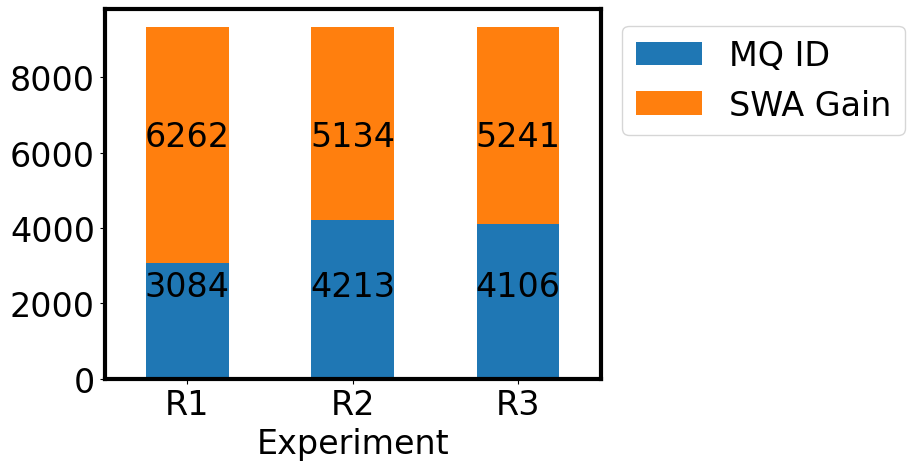

In [20]:
import matplotlib.pyplot as plt

swaps_all.loc[swaps_all["source"] == "both", "Source"] = "MQ ID"
swaps_all.loc[swaps_all["source"] == "ref", "Source"] = "SWA Gain"
plt.rc("font", size=24)  # Set the default font size for all text elements
plt.figure(figsize=(3, 6))  # Set the size of the figure
swaps_all["count"] = 1
swaps_all_pivot = swaps_all.pivot_table(
    index="Experiment",
    columns="Source",
    values="count",
    aggfunc="sum",
    fill_value=0,
)
ax = swaps_all_pivot.plot(kind="bar", stacked=True, legend=True)
ax.legend(bbox_to_anchor=(1.01, 1))
for idx_col, col in enumerate(swaps_all_pivot.columns):
    for idx, val in enumerate(swaps_all_pivot.index):
        ax.text(
            x=idx,
            y=(idx_col * 2 + 1) * 2000,
            s=f"{swaps_all_pivot.loc[val, col]}",
            ha="center",
            va="bottom",
        )
for spine in ax.spines.values():
    spine.set_linewidth(3)  # Increase this value for thicker lines
plt.xticks(rotation=0)
plt.savefig(
    "/cmnfs/proj/ORIGINS/SWAPS_precursor_sampling/bruker_nanoflow/SWAPS_exp/random_15min_MBR/swap_mq_id.png",
    bbox_inches="tight",
    dpi=300,
)

## Run-to-run pair-wise Correlation

In [22]:
R1_R2[["sum_intensity_R1", "sum_intensity_R2"]].apply(lambda x: np.log10(x + 1)).corr(
    method="pearson"
)
R2_R3[["sum_intensity_R2", "sum_intensity_R3"]].apply(lambda x: np.log10(x + 1)).corr(
    method="pearson"
)
R2_R3[["sum_intensity_R1", "sum_intensity_R3"]].apply(lambda x: np.log10(x + 1)).corr(
    method="pearson"
)

,sum_intensity_R1,sum_intensity_R2
sum_intensity_R1,1.000000,0.990832
sum_intensity_R2,0.990832,1.000000


,sum_intensity_R2,sum_intensity_R3
sum_intensity_R2,1.000000,0.991321
sum_intensity_R3,0.991321,1.000000


,sum_intensity_R1,sum_intensity_R3
sum_intensity_R1,1.00000,0.98121
sum_intensity_R3,0.98121,1.00000


### R1 vs R2

In [33]:
# All ID results
from utils.plot import plot_scatter

reg_int, abs_residue, valid_idx = plot_scatter(
    x=R1_R2["sum_intensity_R1"],
    y=R1_R2["sum_intensity_R2"],
    title="",
    x_label="SWA Inferred Intensity R1 (Log10)",
    y_label="SWA Inferred Intensity R2 (Log10)",
    log_x=True,
    log_y=True,
    font_size=20,
    save_dir="/cmnfs/proj/ORIGINS/SWAPS_exp/SWAPS_paper_figures/revision/comparison_MBR/",
    fig_spec_name="scatter_swaps_all_R1_R2",
)

2025-01-23 17:05:03,702 - utils.plot - INFO - Data: sum_intensity_R1_log, sum_intensity_R2_log, slope = 0.983, intercept = -0.167, Pearson's R = 0.991, Spearman's R = 0.991
2025-01-23 17:05:06,448 - utils.plot - INFO - Save plot at /cmnfs/proj/ORIGINS/SWAPS_precursor_sampling/bruker_nanoflow/SWAPS_exp/random_15min_MBR/CorrQuantification_sum_intensity_R2_logscatter_swaps_all_1R_3R.png
2025-01-23 17:05:07,225 - utils.plot - INFO - Save plot at /cmnfs/proj/ORIGINS/SWAPS_precursor_sampling/bruker_nanoflow/SWAPS_exp/random_15min_MBR/CorrQuantification_sum_intensity_R2_logscatter_swaps_all_1R_3R.svg


In [15]:
# Only Exp
from utils.plot import plot_scatter

R1_R2_exp = R1_R2.loc[(R1_R2["source_R1"] == "both") & (R1_R2["source_R2"] == "both")]
reg_int, abs_residue, valid_idx = plot_scatter(
    x=R1_R2_exp["sum_intensity_R1"],
    y=R1_R2_exp["sum_intensity_R2"],
    title="",
    x_label="SWA Inferred Intensity R1 (Log10)",
    y_label="SWA Inferred Intensity R2 (Log10)",
    log_x=True,
    log_y=True,
    font_size=20,
    save_dir="/cmnfs/proj/ORIGINS/SWAPS_exp/SWAPS_paper_figures/revision/comparison_MBR/",
    fig_spec_name="scatter_swaps_exp_R1_R2",
)

2025-01-23 16:36:35,884 - utils.plot - INFO - Data: sum_intensity_R1_log, sum_intensity_R2_log, slope = 0.979, intercept = -0.144, Pearson's R = 0.99, Spearman's R = 0.988
2025-01-23 16:36:36,543 - utils.plot - INFO - Save plot at /cmnfs/proj/ORIGINS/SWAPS_precursor_sampling/bruker_nanoflow/SWAPS_exp/random_15min_MBR/CorrQuantification_sum_intensity_R2_logscatter_swaps_exp_R1_R2.png
2025-01-23 16:36:36,710 - utils.plot - INFO - Save plot at /cmnfs/proj/ORIGINS/SWAPS_precursor_sampling/bruker_nanoflow/SWAPS_exp/random_15min_MBR/CorrQuantification_sum_intensity_R2_logscatter_swaps_exp_R1_R2.svg


In [16]:
# Only Ref
from utils.plot import plot_scatter

R1_R2_ref = R1_R2.loc[(R1_R2["source_R1"] != "both") | (R1_R2["source_R2"] != "both")]
reg_int, abs_residue, valid_idx = plot_scatter(
    x=R1_R2_ref["sum_intensity_R1"],
    y=R1_R2_ref["sum_intensity_R2"],
    title="",
    x_label="SWA Inferred Intensity R1 (Log10)",
    y_label="SWA Inferred Intensity R2 (Log10)",
    log_x=True,
    log_y=True,
    font_size=20,
    save_dir="/cmnfs/proj/ORIGINS/SWAPS_exp/SWAPS_paper_figures/revision/comparison_MBR/",
    fig_spec_name="scatter_swaps_ref_R1_R2",
)

2025-01-23 16:36:42,454 - utils.plot - INFO - Data: sum_intensity_R1_log, sum_intensity_R2_log, slope = 0.983, intercept = -0.168, Pearson's R = 0.991, Spearman's R = 0.991
2025-01-23 16:36:44,906 - utils.plot - INFO - Save plot at /cmnfs/proj/ORIGINS/SWAPS_precursor_sampling/bruker_nanoflow/SWAPS_exp/random_15min_MBR/CorrQuantification_sum_intensity_R2_logscatter_swaps_ref_R1_R2.png
2025-01-23 16:36:45,627 - utils.plot - INFO - Save plot at /cmnfs/proj/ORIGINS/SWAPS_precursor_sampling/bruker_nanoflow/SWAPS_exp/random_15min_MBR/CorrQuantification_sum_intensity_R2_logscatter_swaps_ref_R1_R2.svg


# What is discovered by SWAPS but not by MaxQuant